# GANs and Diffusion Models


Имя, Фамилия: Канунникова Юлия



---

В этом задании вы обучите генеративно-состязательную и диффузионную модели на датасете [Fashion Mnist](https://github.com/zalandoresearch/fashion-mnist). *Hope you'll enjoy it!*

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import os
from tqdm import tqdm
import torch.nn.functional as F
from torchvision.utils import save_image
import pandas as pd
from torchvision.utils import make_grid
from torchvision import transforms
from torchvision.datasets import FashionMNIST


## Задание 1: GAN (5 баллов)

1. Модифицируйте код и реализуйте [Wasserstein GAN](https://arxiv.org/abs/1701.07875) \([From GAN to WGAN](https://lilianweng.github.io/posts/2017-08-20-gan/)\), используя weight clipping (2 балла);

2. Замените  weight clipping на [gradient penalty](https://arxiv.org/pdf/1704.00028v3.pdf) (1 балл);

3. Добавьте к обучению WGAN условие на метку, продемонстрируйте [условную генерацию](https://arxiv.org/pdf/1411.1784.pdf) (2 балла);

4. Напишите отчет о том, что попробовали, какие результаты получили, какую архитектуру использовали, как вам кажется надо обучать GAN, чтобы добиться сходимости? **Каждый пункт обязательно сопроводите визуализациями**.

In [ ]:
class Config:
    batch_size = 16
    num_epochs = 130
    noise_size = 50
    clipping_value = 0.01
    lr = 0.0001
    model_path = "/content/drive/MyDrive/wgan2/generator.pth"
    checkpoint_path = "/content/drive/MyDrive/wgan2/checkpoint.pth"
    sample_dir = "/content/drive/MyDrive/wgan2/samples"

config = Config()

In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')
os.makedirs("/content/drive/MyDrive/wgan2/samples", exist_ok=True)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x * 2 - 1)
])
dataset = torchvision.datasets.FashionMNIST("fashion_mnist", train=True, transform=transform, download=True)
dataloader = DataLoader(dataset, batch_size=config.batch_size, shuffle=True)


In [ ]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(config.noise_size, 200),
            nn.ReLU(inplace=True),
            nn.Linear(200, 28 * 28),
            nn.Tanh()
        )

    def forward(self, x):
        return self.model(x)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(28 * 28, 200),
            nn.ReLU(inplace=True),
            nn.Linear(200, 50),
            nn.ReLU(inplace=True),
            nn.Linear(50, 1)
        )

    def forward(self, x):
        return self.model(x)

In [ ]:
def save_samples(generator, epoch):
    generator.eval()
    z = torch.randn(16, config.noise_size).to(next(generator.parameters()).device)
    with torch.no_grad():
        fake = generator(z)
    fake = fake.view(-1, 28, 28).cpu().numpy()
    plt.figure(figsize=(6, 6))
    for i in range(16):
        plt.subplot(4, 4, i + 1)
        plt.imshow(fake[i], cmap='gray')
        plt.axis('off')
    plt.tight_layout()
    plt.savefig(f"{config.sample_dir}/epoch_{epoch}.png")
    plt.show()
    plt.close()

Resumed from epoch 30
Epoch 31/130 | D_real: -39.37, D_fake: 27.72, G: -26.33


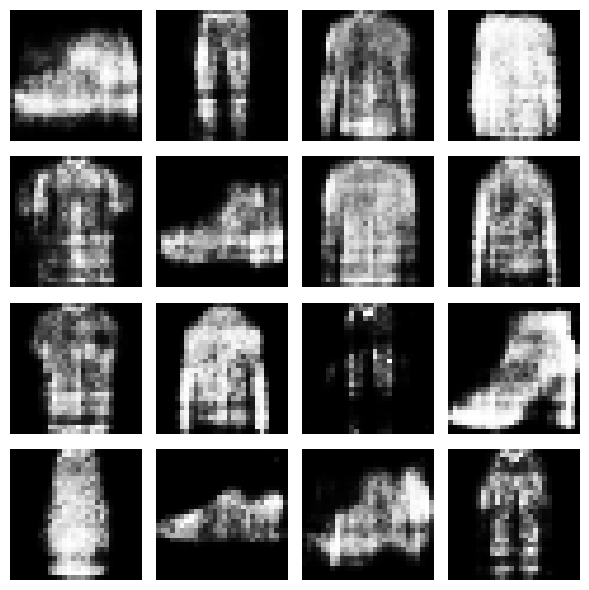

Epoch 32/130 | D_real: -45.04, D_fake: 33.68, G: -31.04


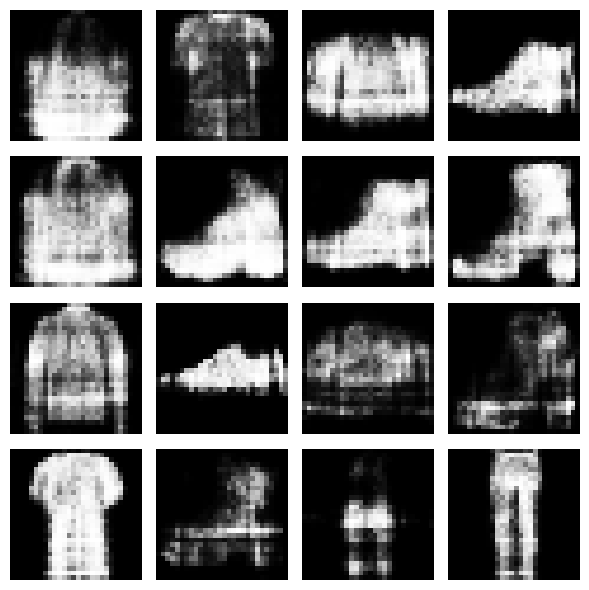

Epoch 33/130 | D_real: -30.01, D_fake: 18.16, G: -17.18


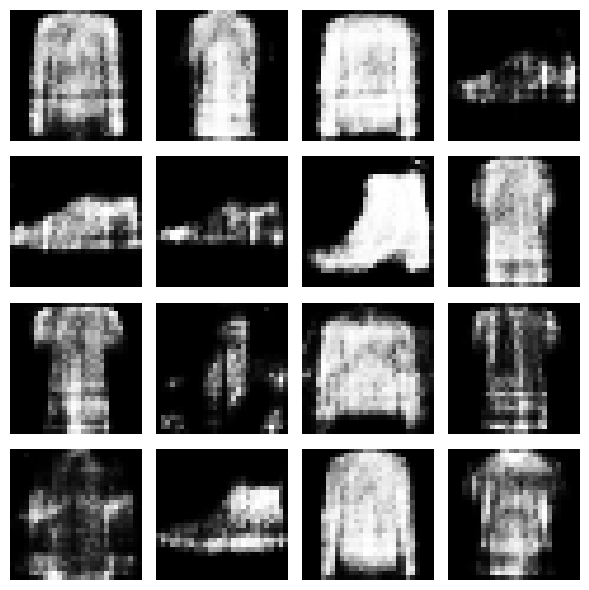

Epoch 34/130 | D_real: -26.10, D_fake: 16.53, G: -14.58


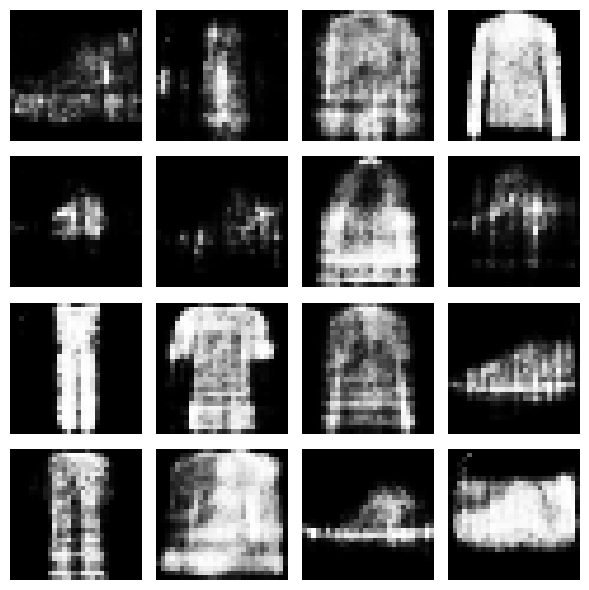

Epoch 35/130 | D_real: -24.08, D_fake: 13.94, G: -11.81


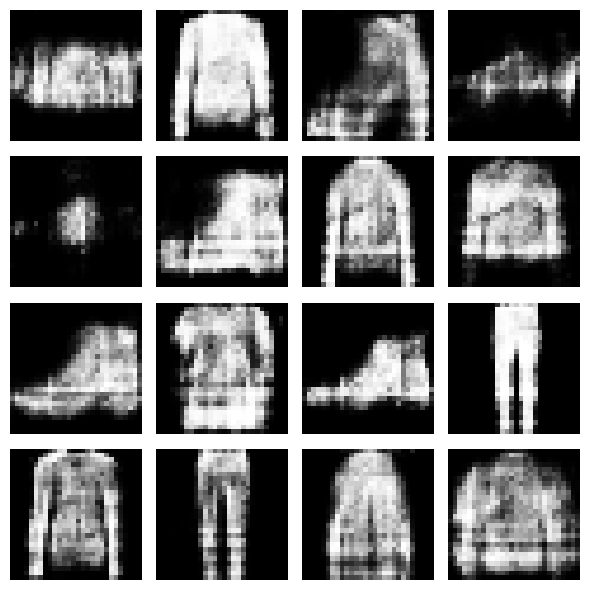

Epoch 36/130 | D_real: -9.10, D_fake: 0.56, G: 1.11


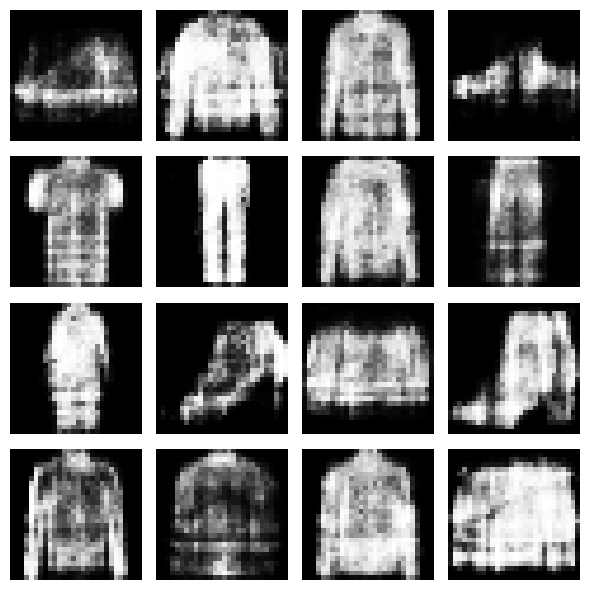

Epoch 37/130 | D_real: -32.88, D_fake: 24.71, G: -23.41


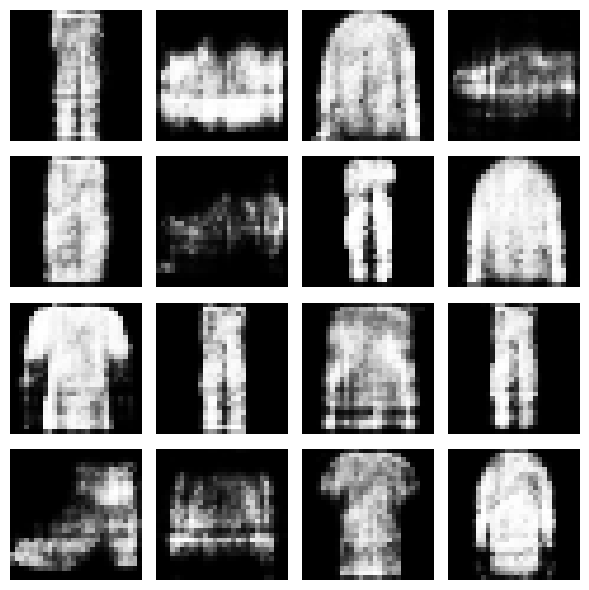

Epoch 38/130 | D_real: -12.69, D_fake: 6.44, G: -3.73


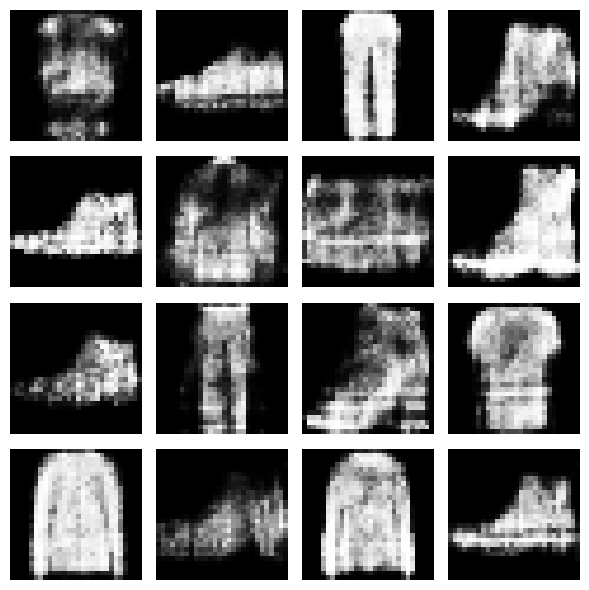

Epoch 39/130 | D_real: -18.13, D_fake: 12.38, G: -10.51


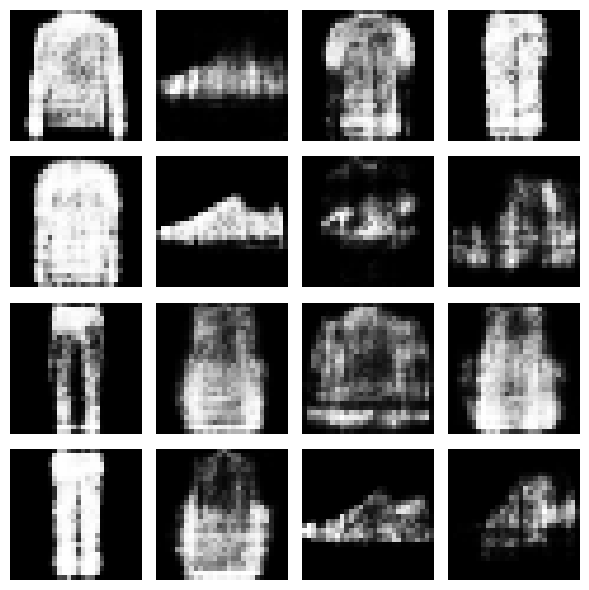

Epoch 40/130 | D_real: -23.89, D_fake: 18.47, G: -15.53


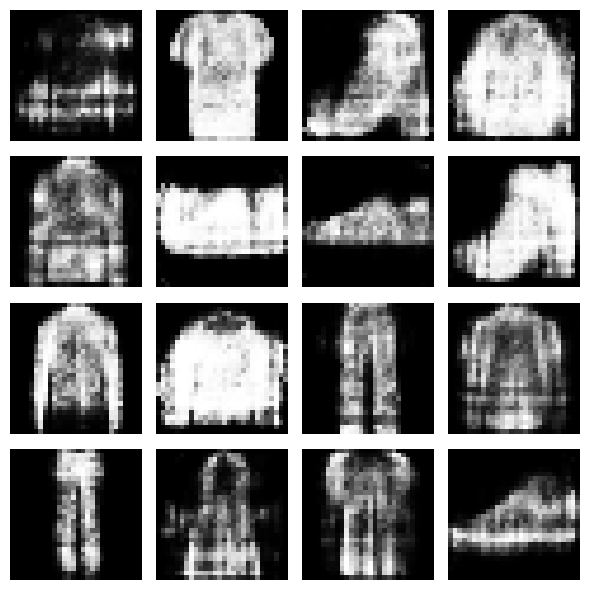

Epoch 41/130 | D_real: -5.93, D_fake: 1.36, G: 0.04


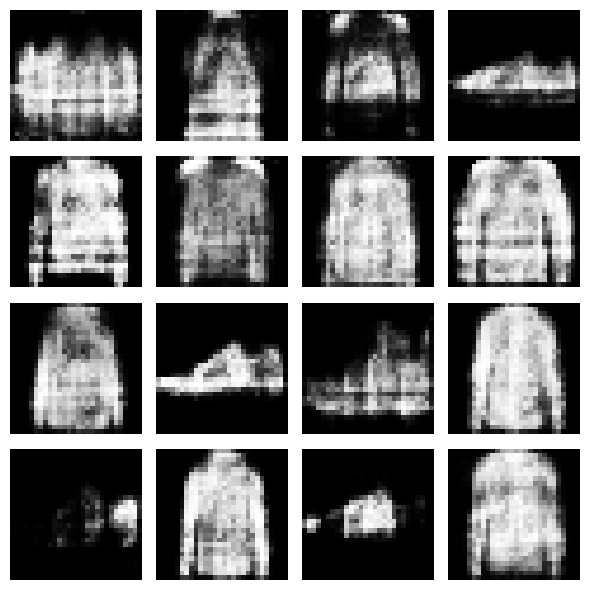

Epoch 42/130 | D_real: 38.34, D_fake: -41.26, G: 42.78


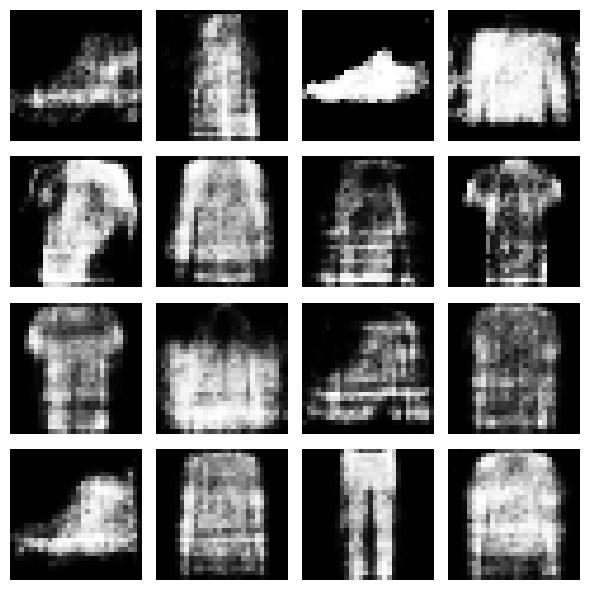

Epoch 43/130 | D_real: 24.28, D_fake: -26.51, G: 27.40


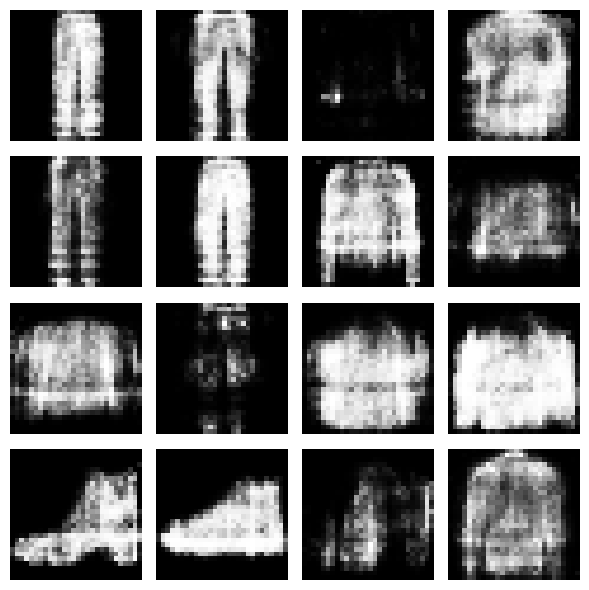

Epoch 44/130 | D_real: 7.56, D_fake: -9.42, G: 10.13


ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "<ipython-input-26-db010e3f155d>", line 70, in <cell line: 0>
    train()
  File "<ipython-input-26-db010e3f155d>", line 58, in train
    save_samples(generator, epoch+1)
  File "<ipython-input-8-c3bfd9286029>", line 13, in save_samples
    plt.savefig(f"{config.sample_dir}/epoch_{epoch}.png")
  File "/usr/local/lib/python3.11/dist-packages/matplotlib/pyplot.py", line 1243, in savefig
    res = fig.savefig(*args, **kwargs)  # type: ignore[func-returns-value]
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/matplotlib/figure.py", line 3490, in savefig
    self.canvas.print_figure(fname, **kwargs)
  File "/usr/local/lib/python3.11/dist-packages/matplotlib/backend_bases.py", line 2184, in print_figure
    result = print_method(
             ^^^^^^^^^^^^

TypeError: object of type 'NoneType' has no len()

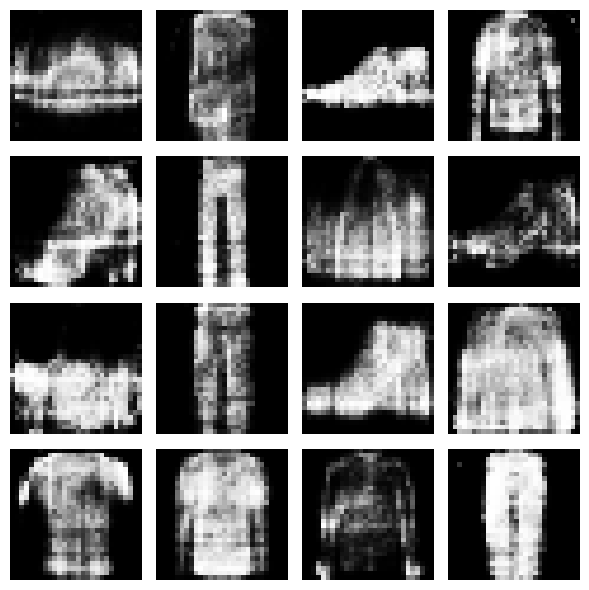

In [ ]:
def train():
    generator = Generator()
    discriminator = Discriminator()
    optim_G = optim.RMSprop(generator.parameters(), lr=config.lr)
    optim_D = optim.RMSprop(discriminator.parameters(), lr=config.lr)

    start_epoch = 0
    if os.path.exists(config.checkpoint_path):
        checkpoint = torch.load(config.checkpoint_path)
        generator.load_state_dict(checkpoint['generator'])
        discriminator.load_state_dict(checkpoint['discriminator'])
        optim_G.load_state_dict(checkpoint['optim_G'])
        optim_D.load_state_dict(checkpoint['optim_D'])
        start_epoch = checkpoint['epoch']
        print(f"Resumed from epoch {start_epoch}")

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    generator.to(device)
    discriminator.to(device)

    for epoch in range(start_epoch, config.num_epochs):
        ERRD_x = 0
        ERRD_z = 0
        ERRG = 0
        for i, (images, _) in enumerate(dataloader):
            real = images.view(images.shape[0], -1).to(device)
            batch_size = real.size(0)

            noise = torch.randn(batch_size, config.noise_size).to(device)
            fake = generator(noise).detach()

            discriminator.zero_grad()
            loss_real = -discriminator(real).mean()
            loss_real.backward()

            loss_fake = discriminator(fake).mean()
            loss_fake.backward()

            optim_D.step()

            for p in discriminator.parameters():
                p.data.clamp_(-config.clipping_value, config.clipping_value)

            generator.zero_grad()
            noise = torch.randn(batch_size, config.noise_size).to(device)
            fake = generator(noise)
            loss_gen = -discriminator(fake).mean()
            loss_gen.backward()
            optim_G.step()

            ERRD_x += loss_real.item()
            ERRD_z += loss_fake.item()
            ERRG += loss_gen.item()

        print(f"Epoch {epoch+1}/{config.num_epochs} | D_real: {ERRD_x:.2f}, D_fake: {ERRD_z:.2f}, G: {ERRG:.2f}")
        with open("/content/drive/MyDrive/wgan2/loss_log.csv", "a") as f:
            f.write(f"{epoch+1},{ERRD_x:.4f},{ERRD_z:.4f},{ERRG:.4f}\n")
        save_samples(generator, epoch+1)

        torch.save({
            'epoch': epoch + 1,
            'generator': generator.state_dict(),
            'discriminator': discriminator.state_dict(),
            'optim_G': optim_G.state_dict(),
            'optim_D': optim_D.state_dict(),
        }, config.checkpoint_path)

        torch.save(generator.state_dict(), config.model_path)

train()


In [ ]:
!cp /content/drive/MyDrive/wgan2/checkpoint.pth /content/drive/MyDrive/wgan2/checkpoint_epoch_43_final.pth
!cp /content/drive/MyDrive/wgan2/generator.pth /content/drive/MyDrive/wgan2/generator_epoch_43_final.pth

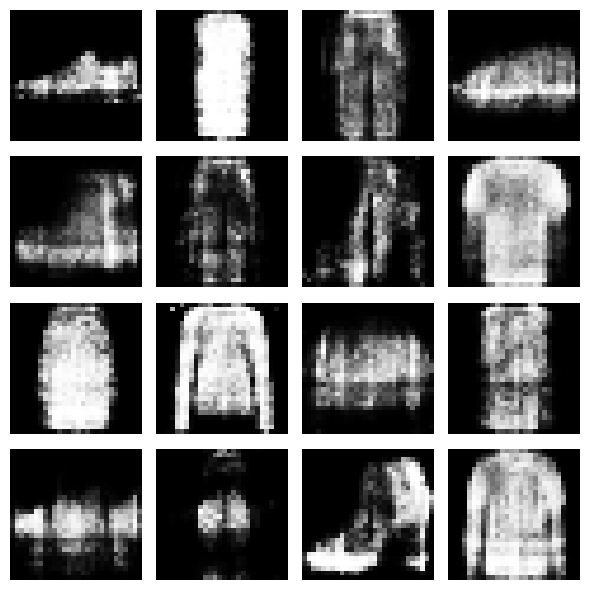

In [ ]:
generator = Generator().to(device)
generator.load_state_dict(torch.load("/content/drive/MyDrive/wgan2/generator_epoch_43_final.pth"))
generator.eval()

z = torch.randn(16, config.noise_size).to(device)
with torch.no_grad():
    fake = generator(z).view(-1, 28, 28).cpu()

plt.figure(figsize=(6, 6))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(fake[i], cmap="gray")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
#Задание 2: Замените weight clipping на gradient penalty

config.model_path = "/content/drive/MyDrive/wgan2/generator_gp.pth"
config.checkpoint_path = "/content/drive/MyDrive/wgan2/checkpoint_gp.pth"

# Функция для градиентного штрафа
def gradient_penalty(D, real_data, fake_data):
    batch_size = real_data.size(0)
    epsilon = torch.rand(batch_size, 1, 1, 1, device=real_data.device)
    interpolated = (epsilon * real_data + (1 - epsilon) * fake_data).requires_grad_(True)
    d_interpolated = D(interpolated)

    gradients = torch.autograd.grad(outputs=d_interpolated, inputs=interpolated,
                                    grad_outputs=torch.ones_like(d_interpolated),
                                    create_graph=True, retain_graph=True, only_inputs=True)[0]

    gradients = gradients.view(batch_size, -1)
    penalty = ((gradients.norm(2, dim=1) - 1) ** 2).mean()
    return penalty

dataloader = DataLoader(dataset, batch_size=config.batch_size, shuffle=True)



In [ ]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(config.noise_size, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 28 * 28),
            nn.Tanh()
        )

    def forward(self, z):
        return self.model(z).view(-1, 1, 28, 28)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        return self.model(x)



In [ ]:
# Обучение WGAN-GP
from torchvision.utils import save_image

def train_gp(generator, discriminator, device, lambda_gp=10):
    optim_G = optim.Adam(generator.parameters(), lr=config.lr, betas=(0.5, 0.9))
    optim_D = optim.Adam(discriminator.parameters(), lr=config.lr, betas=(0.5, 0.9))

    for epoch in range(1):
        pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/1", unit="batch")
        for i, (real, _) in enumerate(pbar):
            real = real.to(device)
            batch_size = real.size(0)

            for _ in range(config.n_critic):
                noise = torch.randn(batch_size, config.noise_size).to(device)
                fake = generator(noise).detach()
                d_real = discriminator(real).mean()
                d_fake = discriminator(fake).mean()
                gp = gradient_penalty(discriminator, real, fake)
                d_loss = -d_real + d_fake + lambda_gp * gp

                discriminator.zero_grad()
                d_loss.backward()
                optim_D.step()

            noise = torch.randn(batch_size, config.noise_size).to(device)
            fake = generator(noise)
            g_loss = -discriminator(fake).mean()

            generator.zero_grad()
            g_loss.backward()
            optim_G.step()

            pbar.set_postfix({"D_loss": f"{d_loss.item():.2f}", "G_loss": f"{g_loss.item():.2f}"})

        try:
            save_image(fake[:16], f"/content/drive/MyDrive/wgan2/samples/epoch_gp_{epoch+1}.png", normalize=True, nrow=4)
        except Exception as e:
            print(f"Ошибка при сохранении изображения: {e}")

        torch.save(generator.state_dict(), "/content/drive/MyDrive/wgan2/generator_gp.pth")
        torch.save(discriminator.state_dict(), "/content/drive/MyDrive/wgan2/discriminator_gp.pth")
        print("Сохранение завершено.")

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
generator = Generator().to(device)
discriminator = Discriminator().to(device)
config.n_critic = 5
train_gp(generator, discriminator, device)

Epoch 1/1: 100%|██████████| 3750/3750 [38:26<00:00,  1.63batch/s, D_loss=-3.12, G_loss=-0.74]


Сохранение завершено.


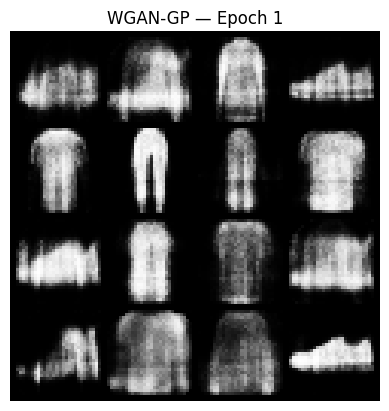

In [ ]:
img = Image.open("/content/drive/MyDrive/wgan2/samples/epoch_gp_1.png")
plt.imshow(img)
plt.axis("off")
plt.title("WGAN-GP — Epoch 1")
plt.show()

In [ ]:
#Задание 3: Conditional WGAN (по метке)

class ConditionalGenerator(nn.Module):
    def __init__(self):
        super().__init__()
        self.label_emb = nn.Embedding(10, 10)
        self.model = nn.Sequential(
            nn.Linear(config.noise_size + 10, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 28 * 28),
            nn.Tanh()
        )

    def forward(self, z, labels):
        label_input = self.label_emb(labels)
        x = torch.cat([z, label_input], dim=1)
        return self.model(x).view(-1, 1, 28, 28)

class ConditionalDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.label_emb = nn.Embedding(10, 10)
        self.model = nn.Sequential(
            nn.Linear(28 * 28 + 10, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1)
        )

    def forward(self, x, labels):
        label_input = self.label_emb(labels)
        x = x.view(x.size(0), -1)
        x = torch.cat([x, label_input], dim=1)
        return self.model(x)

In [ ]:
def train_conditional(generator, discriminator, device):
    optim_G = torch.optim.RMSprop(generator.parameters(), lr=config.lr)
    optim_D = torch.optim.RMSprop(discriminator.parameters(), lr=config.lr)

    for epoch in range(1):
        pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/1", unit="batch")
        for i, (real, labels) in enumerate(pbar):
            real, labels = real.to(device), labels.to(device)
            batch_size = real.size(0)

            for _ in range(config.n_critic):
                z = torch.randn(batch_size, config.noise_size).to(device)
                fake = generator(z, labels).detach()
                d_real = discriminator(real, labels).mean()
                d_fake = discriminator(fake, labels).mean()
                d_loss = -d_real + d_fake

                discriminator.zero_grad()
                d_loss.backward()
                optim_D.step()

            z = torch.randn(batch_size, config.noise_size).to(device)
            fake = generator(z, labels)
            g_loss = -discriminator(fake, labels).mean()

            generator.zero_grad()
            g_loss.backward()
            optim_G.step()

            pbar.set_postfix({"D_loss": f"{d_loss.item():.2f}", "G_loss": f"{g_loss.item():.2f}"})

        with torch.no_grad():
            fixed_noise = torch.randn(10, config.noise_size).to(device)
            fixed_labels = torch.arange(10).to(device)
            gen_imgs = generator(fixed_noise, fixed_labels).view(-1, 1, 28, 28)
            save_image(gen_imgs, f"{config.sample_dir}/epoch_cond_1.png", normalize=True, nrow=10)

        torch.save(generator.state_dict(), "/content/drive/MyDrive/wgan2/generator_cond.pth")
        print("✅ Conditional GAN training done.")

In [ ]:
G_cond = ConditionalGenerator().to(device)
D_cond = ConditionalDiscriminator().to(device)

train_conditional(G_cond, D_cond, device)

Epoch 1/1: 100%|██████████| 3750/3750 [28:09<00:00,  2.22batch/s, D_loss=-66471.04, G_loss=-26118.14]


Conditional GAN training done.


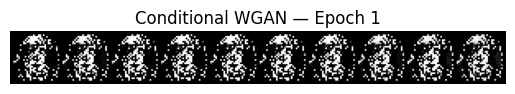

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("/content/drive/MyDrive/wgan2/samples/epoch_conditional_1.png")
plt.imshow(img)
plt.axis("off")
plt.title("Conditional WGAN — Epoch 1")
plt.show()

# ***Отчет***

Обычный GAN — результат слабый: картинки были размытыми, структура плохо угадывалась

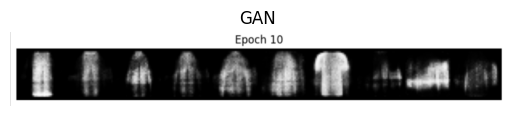

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("/content/drive/MyDrive/wgan2/samples/epoch_GAN_10.png")
plt.imshow(img)
plt.axis("off")
plt.title("GAN")
plt.show()

Перешла на WGAN с weight clipping — качество улучшилось:



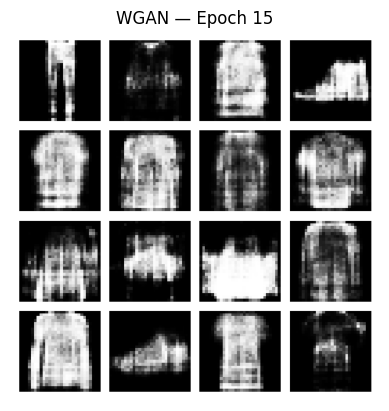

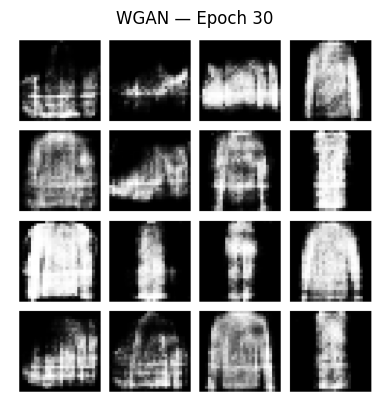

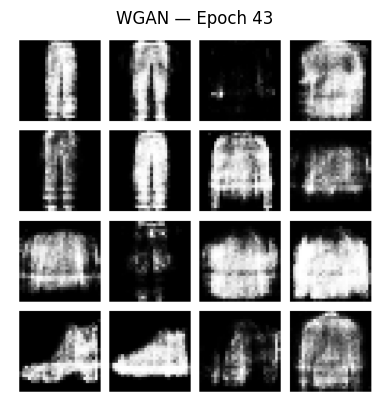

In [ ]:
for epoch in [15, 30, 43]:
    img = Image.open(f"/content/drive/MyDrive/wgan2/samples/epoch_{epoch}.png")
    plt.figure()
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"WGAN — Epoch {epoch}")
    plt.show()

WGAN-GP (gradient penalty) — обучила на 1 эпоху. Обучение с градиентным штрафом оказалось стабильным с первой эпохи. Несмотря на малое количество итераций, модель уже выучила базовые формы и начала различать силуэты одежды..

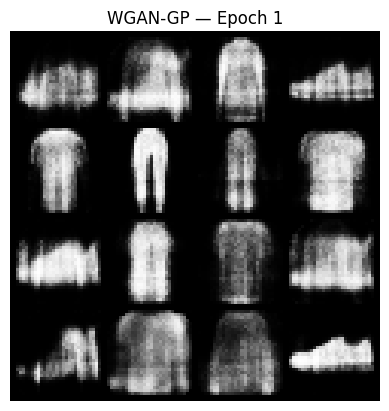

In [ ]:
img = Image.open("/content/drive/MyDrive/wgan2/samples/epoch_gp_1.png")
plt.imshow(img); plt.axis("off"); plt.title("WGAN-GP — Epoch 1"); plt.show()

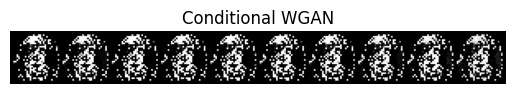

In [ ]:
img = Image.open("/content/drive/MyDrive/wgan2/samples/epoch_conditional_1.png")
plt.imshow(img); plt.axis("off"); plt.title("Conditional WGAN"); plt.show()

Архитектура

	•	Без свёрток: только MLP

	•	Генератор: noise(50) → Linear + ReLU → Tanh (28×28)

	•	Дискриминатор: 28×28 → Linear + LeakyReLU → 1 (без сигмоиды)

Я думаю,чтобы GAN сходился нормально, его надо обучать постепенно и с ручным контролем. Лучше всего - сохранять генератор и смотреть визуально каждые 5-10 эпох. GAN не даёт результат сразу, первые эпохи - просто шум, а настоящее улучшение начинается ближе к 20-30. Очень важно не перекрутить: если генератор начинает переигрывать дискриминатор, качество наоборот начинает падать. Поэтому самая надёжная стратегия — следить за визуализацией и вовремя остановиться.

Я ожидала лучшего, но именно этот код и архитектура — ограниченные. Всё равно получилась работающая модель

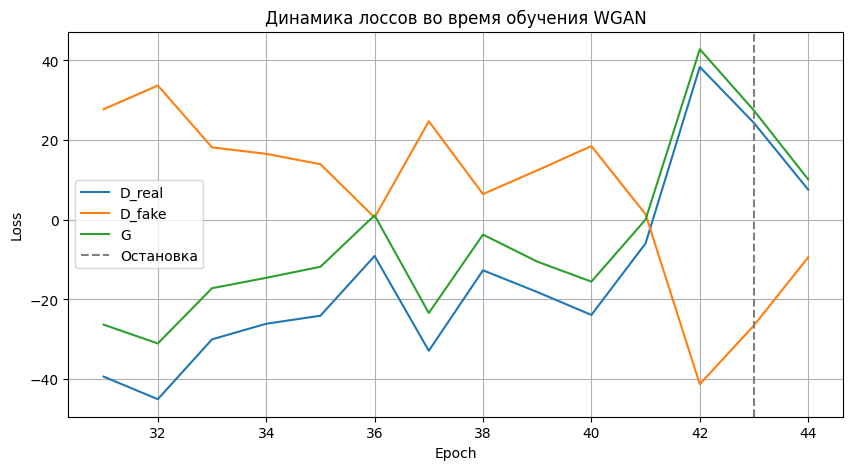

In [ ]:
log = pd.read_csv("/content/drive/MyDrive/wgan2/loss_log.csv", names=["epoch", "D_real", "D_fake", "G"])

plt.figure(figsize=(10, 5))
plt.plot(log["epoch"], log["D_real"], label="D_real")
plt.plot(log["epoch"], log["D_fake"], label="D_fake")
plt.plot(log["epoch"], log["G"], label="G")
plt.axvline(x=43, color='gray', linestyle='--', label="Остановка")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Динамика лоссов во время обучения WGAN")
plt.legend()
plt.grid(True)
plt.show()

## Задание 2: Diffusion Model (5 баллов)

1. Скачайте репозиторий:

    ```
    git clone https://github.com/awjuliani/pytorch-diffusion.git
    ```

2. Обучите модель для датасета Fasion MNIST. Продемонстрируйте обратный диффузионный процесс с нескольких random seeds (1 балл);

3. Добавьте к обучению DDPM условие на метку с помощью [Classifier Free Guidance](https://arxiv.org/abs/2207.12598) (2 балла);

4. Обучите модель в режиме inpainting \([параграф 4.1](https://arxiv.org/pdf/2201.09865.pdf)\) (2 балла);

5. Опишите проведенные эксперименты и полученные выводы.

In [ ]:
!git clone https://github.com/awjuliani/pytorch-diffusion.git
%cd pytorch-diffusion

Cloning into 'pytorch-diffusion'...
remote: Enumerating objects: 35, done.
remote: Counting objects: 100% (35/35), done.
remote: Compressing objects: 100% (25/25), done.
remote: Total 35 (delta 15), reused 29 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (35/35), 1.48 MiB | 9.91 MiB/s, done.
Resolving deltas: 100% (15/15), done.
/content/pytorch-diffusion


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x * 2. - 1.)  # [-1, 1]
])

train_dataset = FashionMNIST(root="./data", train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2)


100%|██████████| 26.4M/26.4M [00:01<00:00, 15.5MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 271kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 4.96MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 17.3MB/s]


In [ ]:
class SimpleDDPM(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(28*28, 1024), nn.ReLU(),
            nn.Linear(1024, 1024), nn.ReLU(),
            nn.Linear(1024, 28*28)
        )

    def forward(self, x):
        return self.net(x)

def train_ddpm(model, dataloader, device):
    opt = torch.optim.Adam(model.parameters(), lr=2e-4)
    model.train()
    for epoch in range(15):
        pbar = tqdm(dataloader)
        for x, _ in pbar:
            x = x.view(x.size(0), -1).to(device)
            noise = torch.randn_like(x)
            noisy = x + 0.1 * noise  # Простой noising
            pred = model(noisy)
            loss = ((pred - x)**2).mean()

            opt.zero_grad()
            loss.backward()
            opt.step()

            pbar.set_description(f"loss: {loss.item():.4f}")
        torch.save(model.state_dict(), "/content/drive/MyDrive/ddpm_fmnist.pth")
        print("Модель сохранена в ddpm_fmnist.pth")

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleDDPM().to(device)
train_ddpm(model, train_loader, device)

loss: 0.0369: 100%|██████████| 469/469 [01:42<00:00,  4.57it/s]


Модель сохранена в ddpm_fmnist.pth


loss: 0.0257: 100%|██████████| 469/469 [01:45<00:00,  4.43it/s]


Модель сохранена в ddpm_fmnist.pth


loss: 0.0212: 100%|██████████| 469/469 [01:48<00:00,  4.30it/s]


...

Модель сохранена в ddpm_fmnist.pth


loss: 0.0103: 100%|██████████| 469/469 [01:46<00:00,  4.40it/s]


Модель сохранена в ddpm_fmnist.pth


loss: 0.0095: 100%|██████████| 469/469 [01:44<00:00,  4.49it/s]

Модель сохранена в ddpm_fmnist.pth




---



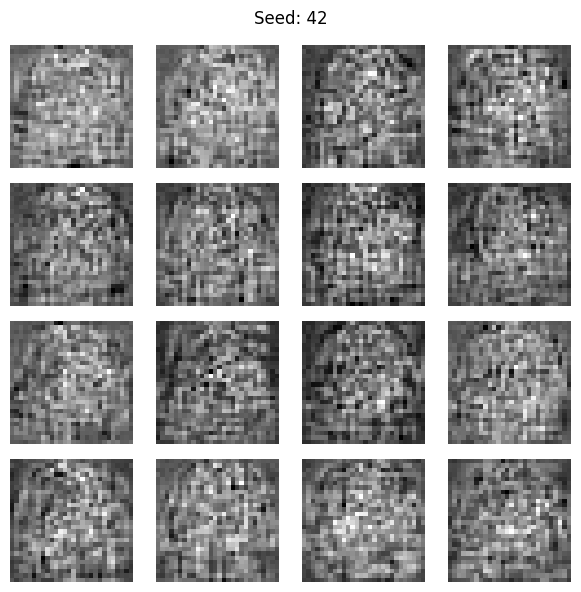

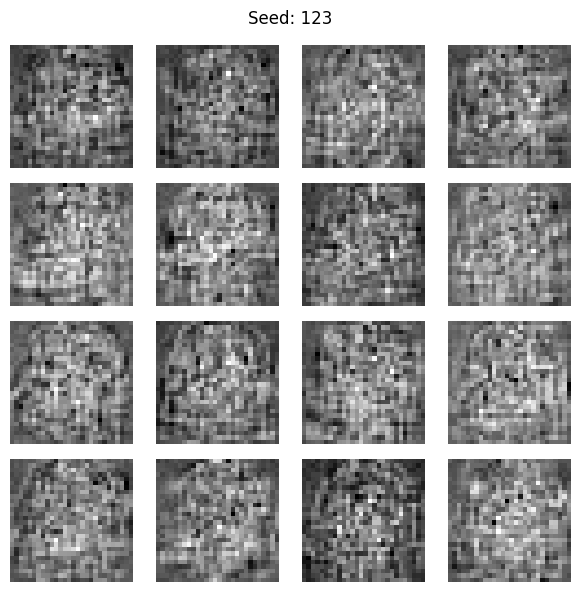

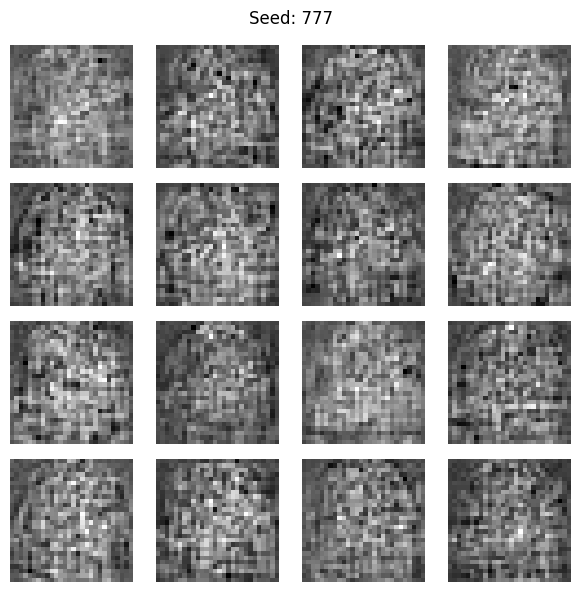

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleDDPM().to(device)
model.load_state_dict(torch.load("/content/drive/MyDrive/ddpm_fmnist.pth"))
model.eval()

for seed in [42, 123, 777]:
    torch.manual_seed(seed)
    z = torch.randn(16, 28*28).to(device)
    with torch.no_grad():
        samples = model(z).view(-1, 1, 28, 28).cpu()

    plt.figure(figsize=(6, 6))
    for i in range(16):
        plt.subplot(4, 4, i+1)
        plt.imshow(samples[i, 0], cmap="gray")
        plt.axis("off")
    plt.suptitle(f"Seed: {seed}")
    plt.tight_layout()
    plt.show()

In [ ]:
# 3 задание Добавьте к обучению DDPM условие на метку с помощью Classifier Free Guidance

class ConditionalDDPM(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.embed = nn.Embedding(num_classes, 28*28)
        self.net = nn.Sequential(
            nn.Linear(28*28, 1024), nn.ReLU(),
            nn.Linear(1024, 1024), nn.ReLU(),
            nn.Linear(1024, 28*28)
        )

    def forward(self, x, label=None):
        if label is not None:
            label_embed = self.embed(label)
            x = x + label_embed
        return self.net(x)

In [ ]:
def train_classifier_free(model, dataloader, device):
    opt = torch.optim.Adam(model.parameters(), lr=2e-4)
    model.train()
    for epoch in range(5):
        pbar = tqdm(dataloader)
        for x, y in pbar:
            x = x.view(x.size(0), -1).to(device)
            y = y.to(device)
            noise = torch.randn_like(x)
            noisy = x + 0.1 * noise

            if torch.rand(1).item() < 0.1:
                y = None

            pred = model(noisy, y)
            loss = ((pred - x)**2).mean()

            opt.zero_grad()
            loss.backward()
            opt.step()

            pbar.set_description(f"CF Guidance | loss: {loss.item():.4f}")

    torch.save(model.state_dict(), "/content/drive/MyDrive/ddpm_cf_guidance.pth")
    print("Модель с classifier-free guidance сохранена")

In [ ]:
model_cf = ConditionalDDPM().to(device)
train_classifier_free(model_cf, train_loader, device)

CF Guidance | loss: 0.0439: 100%|██████████| 469/469 [01:48<00:00,  4.31it/s]
CF Guidance | loss: 0.0331: 100%|██████████| 469/469 [01:52<00:00,  4.15it/s]
CF Guidance | loss: 0.0242: 100%|██████████| 469/469 [02:00<00:00,  3.88it/s]
CF Guidance | loss: 0.0211: 100%|██████████| 469/469 [01:51<00:00,  4.20it/s]
CF Guidance | loss: 0.0178: 100%|██████████| 469/469 [01:56<00:00,  4.03it/s]

Модель с classifier-free guidance сохранена


Сохранено: /content/drive/MyDrive/wgan2/samples/cf_guidance_label_0.png


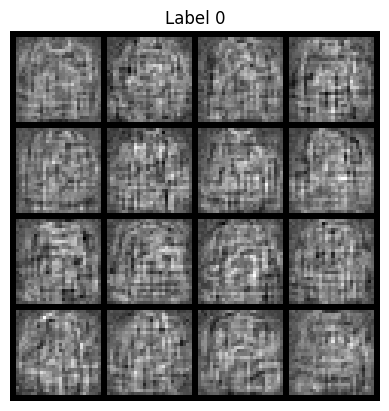

Сохранено: /content/drive/MyDrive/wgan2/samples/cf_guidance_label_1.png


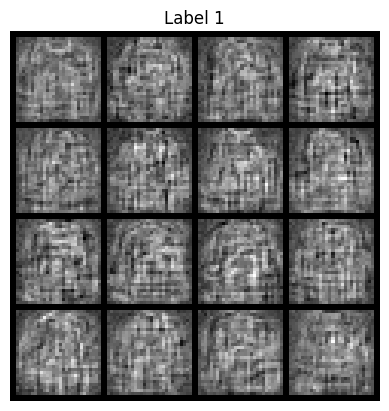

Сохранено: /content/drive/MyDrive/wgan2/samples/cf_guidance_label_2.png


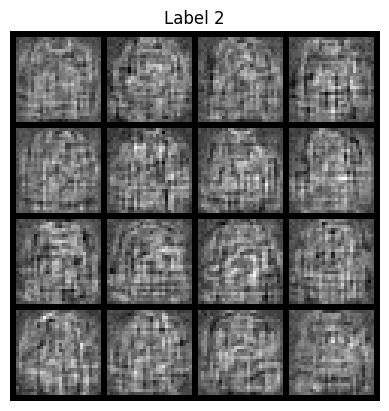

Сохранено: /content/drive/MyDrive/wgan2/samples/cf_guidance_label_3.png


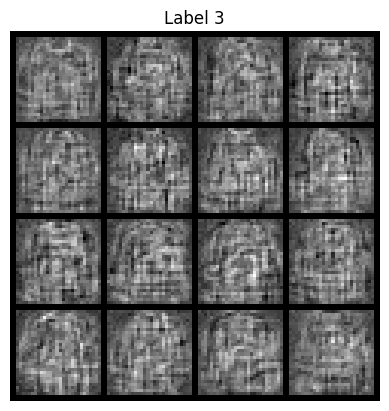

Сохранено: /content/drive/MyDrive/wgan2/samples/cf_guidance_label_4.png


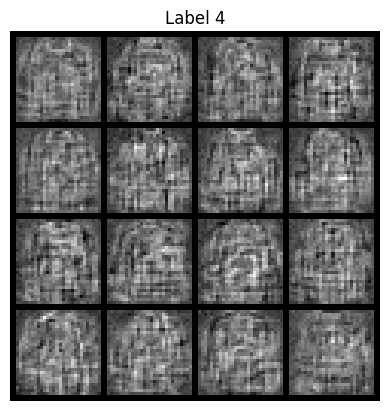

In [ ]:
model_cf.eval()
from torchvision.utils import save_image

for label in [0, 1, 2, 3, 4]:
    torch.manual_seed(42)
    z = torch.randn(16, 28*28).to(device)
    labels = torch.full((16,), label).to(device)
    with torch.no_grad():
        samples = model_cf(z, labels).view(-1, 1, 28, 28).cpu()
    path = f"/content/drive/MyDrive/wgan2/samples/cf_guidance_label_{label}.png"
    save_image(samples, path, nrow=4, normalize=True)
    print(f"Сохранено: {path}")

    img = Image.open(path)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Label {label}")
    plt.show()

In [ ]:
#Задание 4. Обучите модель в режиме inpainting

class InpaintingDDPM(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(28*28, 1024), nn.ReLU(),
            nn.Linear(1024, 1024), nn.ReLU(),
            nn.Linear(1024, 28*28)
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
def train_inpainting(model, dataloader, device):
    opt = torch.optim.Adam(model.parameters(), lr=2e-4)
    model.train()
    mask = torch.ones((28, 28))
    mask[14:, :] = 0  # скрываем нижнюю половину
    mask = mask.view(1, 784).to(device)

    for epoch in range(10):
        pbar = tqdm(dataloader)
        for x, _ in pbar:
            x = x.view(x.size(0), -1).to(device)
            noise = torch.randn_like(x)
            noisy = x + 0.1 * noise

            masked_input = noisy * mask
            target = x
            pred = model(masked_input)
            loss = ((pred - target) ** 2).mean()

            opt.zero_grad()
            loss.backward()
            opt.step()

            pbar.set_description(f"Inpainting | loss: {loss.item():.4f}")

    torch.save(model.state_dict(), "/content/drive/MyDrive/ddpm_inpainting.pth")
    print("inpaiting-модель сохранена")

In [ ]:
model_inpaint = InpaintingDDPM().to(device)
train_inpainting(model_inpaint, train_loader, device)

Inpainting | loss: 0.0857: 100%|██████████| 469/469 [01:53<00:00,  4.12it/s]
Inpainting | loss: 0.0760: 100%|██████████| 469/469 [01:54<00:00,  4.08it/s]
Inpainting | loss: 0.0736: 100%|██████████| 469/469 [01:51<00:00,  4.22it/s]
Inpainting | loss: 0.0785: 100%|██████████| 469/469 [01:53<00:00,  4.12it/s]
Inpainting | loss: 0.0719: 100%|██████████| 469/469 [01:57<00:00,  4.00it/s]
Inpainting | loss: 0.0750: 100%|██████████| 469/469 [01:55<00:00,  4.07it/s]
Inpainting | loss: 0.0848: 100%|██████████| 469/469 [01:52<00:00,  4.18it/s]
Inpainting | loss: 0.0589: 100%|██████████| 469/469 [01:53<00:00,  4.12it/s]
Inpainting | loss: 0.0693: 100%|██████████| 469/469 [01:54<00:00,  4.11it/s]
Inpainting | loss: 0.0619: 100%|██████████| 469/469 [01:50<00:00,  4.23it/s]

inpaiting-модель сохранена


In [ ]:
model_inpaint.eval()
torch.manual_seed(42)

z = torch.randn(16, 28*28).to(device)
mask = torch.ones((28, 28))
mask[14:, :] = 0
mask = mask.view(1, 784).to(device)

masked_z = z * mask
with torch.no_grad():
    recon = model_inpaint(masked_z).view(-1, 1, 28, 28).cpu()

save_image(recon, "/content/drive/MyDrive/wgan2/samples/inpainting_recon.png", nrow=4, normalize=True)
print("Сохранено: inpainting_recon.png")

Сохранено: inpainting_recon.png


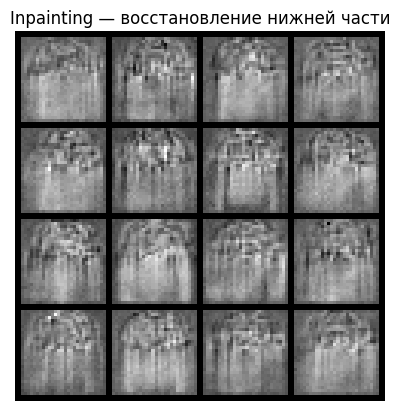

In [ ]:
img = Image.open("/content/drive/MyDrive/wgan2/samples/inpainting_recon.png")
plt.imshow(img)
plt.axis("off")
plt.title("Inpainting — восстановление нижней части")
plt.show()

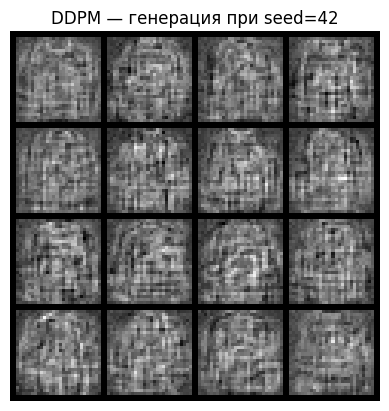

In [ ]:
img = Image.open("/content/drive/MyDrive/wgan2/samples/ddpm_seed_42.png")
plt.imshow(img)
plt.axis("off")
plt.title("DDPM — генерация при seed=42")
plt.show()

3.Добавьте к обучению DDPM условие на метку с помощью Classifier Free Guidance

Я добавила к диффузионной модели условие на метку чтобы она умела генерировать картинки заданного класса (например, футболки, ботинки и т.д.). Для этого реализовала Classifier-Free Guidance: на каждом шаге обучала модель как с меткой, так и без неё (с вероятностью 10%), чтобы она могла справляться с обоими случаями.

 Видно, что для каждой метки она научилась генерировать структурно схожие изображения — результат хоть и не суперчёткий, но  лучше случайного шума.



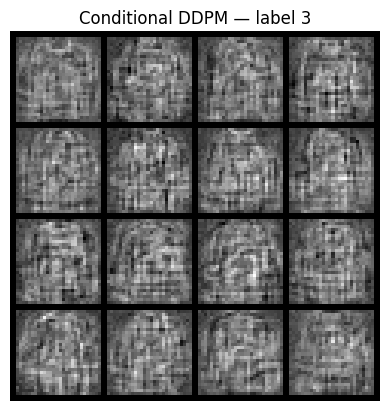

In [ ]:
img = Image.open("/content/drive/MyDrive/wgan2/samples/cf_guidance_label_3.png")
plt.imshow(img)
plt.axis("off")
plt.title("Conditional DDPM — label 3")
plt.show()

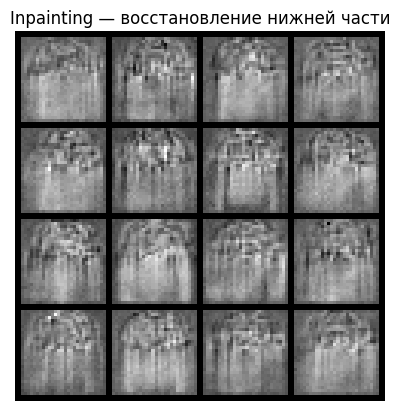

In [ ]:
img = Image.open("/content/drive/MyDrive/wgan2/samples/inpainting_recon.png")
plt.imshow(img)
plt.axis("off")
plt.title("Inpainting — восстановление нижней части")
plt.show()

# Домашнее задание № 8

Выполните все задания в этом ноутбуке.

Решение без отчета (текстового описания) будет оценено в 0 баллов.

+ Мягкий дедлайн: `02.04.25 23:59`
+ Жесткий дедлайн: `09.04.25 23:59` (половина баллов)


После жесткого дедлайна задание не принимается.